In [1]:
#### IMOPRTING THE Libraries

In [2]:
import numpy as np
import pandas as pd
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv('airline_passenger_satisfaction.csv')
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


#### Target Variable
- Column Name: Satisfaction
- Description: Indicates whether the passenger is satisfied
- Type: Categorical
- Satisfied → Happy customer
- Neutral or Dissatisfied → Unhappy customer
- This over Traget varible that we are going to work on it

### STEP:1 BASICES CHECK

In [4]:
#### IT PROVIDE THE TOP INFORMATION FORM THE DATASET TABLE
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [5]:
### IN THIS DF.TAIL() SHOW THE BOTTEM OF THE TABLE INFORMATIION
df.tail()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied
129879,129880,Female,20,Returning,Personal,Economy Plus,337,0,0.0,1,...,4,2,4,2,2,2,3,2,1,Neutral or Dissatisfied


In [6]:
df.nunique()

ID                                        129880
Gender                                         2
Age                                           75
Customer Type                                  2
Type of Travel                                 2
Class                                          3
Flight Distance                             3821
Departure Delay                              466
Arrival Delay                                472
Departure and Arrival Time Convenience         6
Ease of Online Booking                         6
Check-in Service                               6
Online Boarding                                6
Gate Location                                  6
On-board Service                               6
Seat Comfort                                   6
Leg Room Service                               6
Cleanliness                                    6
Food and Drink                                 6
In-flight Service                              6
In-flight Wifi Servi

In [7]:
### IT PROVIDE THE SHAPE OF THE  TABLE HOW THE COLUMN AND ROW ODTINED THE SPACE
df.shape

(129880, 24)

In [8]:
#### IN THE DF.INFO() THE COMPLETE INFORMATION ABOUT THE COMPLETE DETAILS OD THE DATA SET 
### EACH COLUMN IS CONSIST OF INT64, FLOAT64, OBJECT ETCC... 
### AND HOW MANY ROW AND COLUMNS IN THE DATASET ARE PRESERNT 
### AND IDENTIFY THE DUPLICATES IN THE DATA SET OVERALL
### THIS DF.INFO() PROVIDES THE OVERALL INFORMATION OF THE DATASET
### IN THIS WE CAN UNDERSTAND THE DATASET COMPLETLY
### IN THIS TOTAL 5 OBJECT AND 19 NUMERICAL CLOUMNS ARE PRESENT IN THIS DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

In [9]:
### DF.DESCRIBE() SHOW THE MAX, MIN, MEAN, MEDIAN, MODE, STANERD DEVATION, Q1 - Q3 VALUES OF THE EACH COLUMNS IN THE DATASET
df.describe()

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


#### STEP:2 DATA CLEANING

In [10]:
### Remove unwanted columns
### In this ID column is not required 

In [11]:
df.drop("ID", axis=1, inplace=True)

#### Missing values
- in this df.isnull().sum() we need to identify the missing values which are present in the dataset

In [12]:
df.isnull().sum()

Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment                     0
Baggage Handling                  

In [13]:
df['Arrival Delay'] = df['Arrival Delay'].fillna(df['Arrival Delay'].median())
df['Arrival Delay']

0          5.0
1         39.0
2          0.0
3          0.0
4          1.0
          ... 
129875     3.0
129876     0.0
129877    14.0
129878    22.0
129879     0.0
Name: Arrival Delay, Length: 129880, dtype: float64

In [14]:
### Recheck it
### and the is not missing values in the dataset
df.isnull().sum()

Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                          0
Satisfaction                    

In [15]:
### Now we have to identify the duplicates in the dataset by using df.duplicated().sum()
### And there is no duplicates in the dataset are present in the dataset
df.duplicated().sum()

np.int64(0)

#### Data Cleaning is completed and Data is cleaned completly now

#### STEP:3 Exploratory Data Analysis (EDA)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

### Target Distribution

<Axes: xlabel='Satisfaction', ylabel='count'>

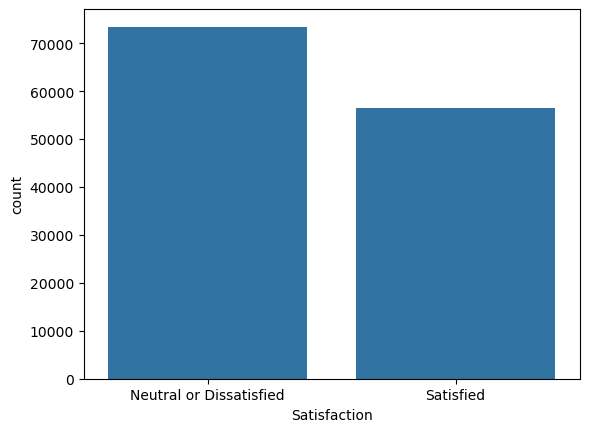

In [17]:
### Here we will identify the Balanced or imbalanced? whether it is "satisfied" or " Neutral or Dissatisfied"
sns.countplot(x='Satisfaction', data=df)

### Gender vs Satisfaction
- It show the difference btw the Gender and Satisfaction 

<Axes: xlabel='Gender', ylabel='count'>

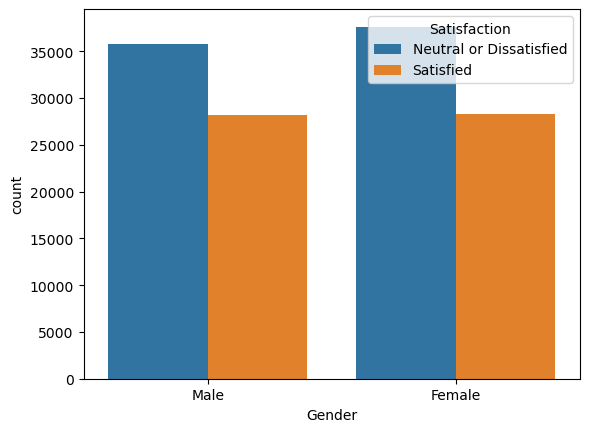

In [18]:
sns.countplot(x="Gender", hue="Satisfaction",data=df)

### Customer Type vs Satisfaction

<Axes: xlabel='Customer Type', ylabel='count'>

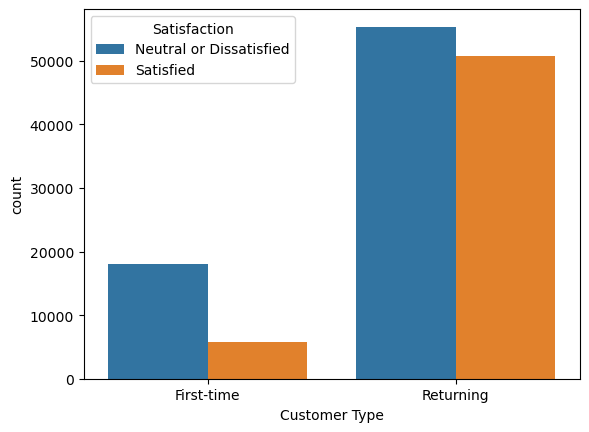

In [19]:
sns.countplot(x="Customer Type", hue="Satisfaction",data=df)
# in the customer types returning is more satisfied and N or D

### Type of Travel

<Axes: xlabel='Type of Travel', ylabel='count'>

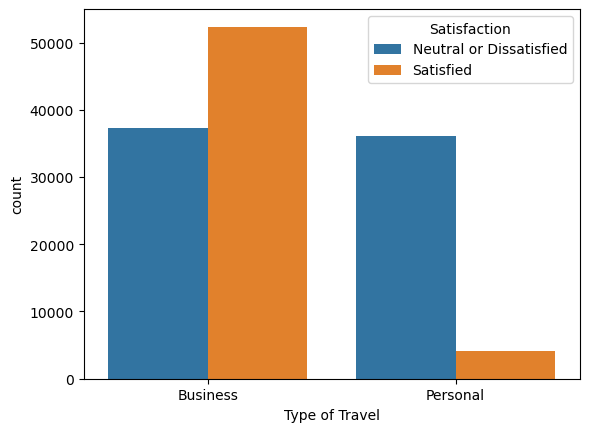

In [20]:
sns.countplot(x="Type of Travel", hue="Satisfaction",data=df)
### Business is more satisfaction

### Class Analysis

<Axes: xlabel='Class', ylabel='count'>

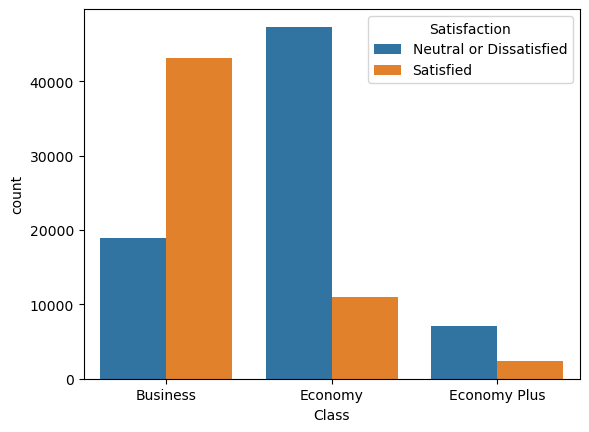

In [21]:
sns.countplot(x="Class", hue="Satisfaction",data=df)
### Business class usually higher satisfaction.

### Delay Analysis

<Axes: xlabel='Satisfaction', ylabel='Departure Delay'>

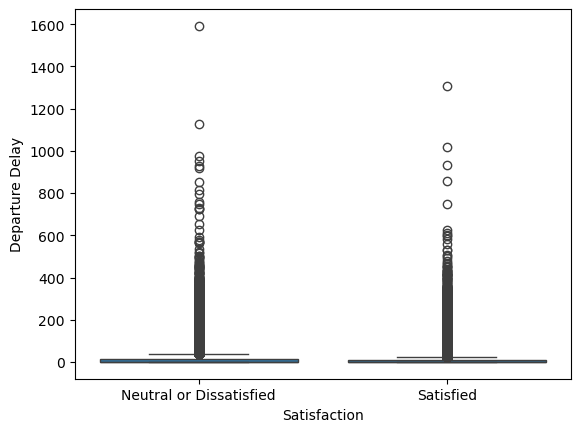

In [22]:
sns.boxplot(x="Satisfaction",y= "Departure Delay",data = df)
## delays reduce happiness yes becaue the D is presnent more

### Service Ratings Correlation
-- Find strongest predictors.

-- correlation we have to use only for the numerical columns only

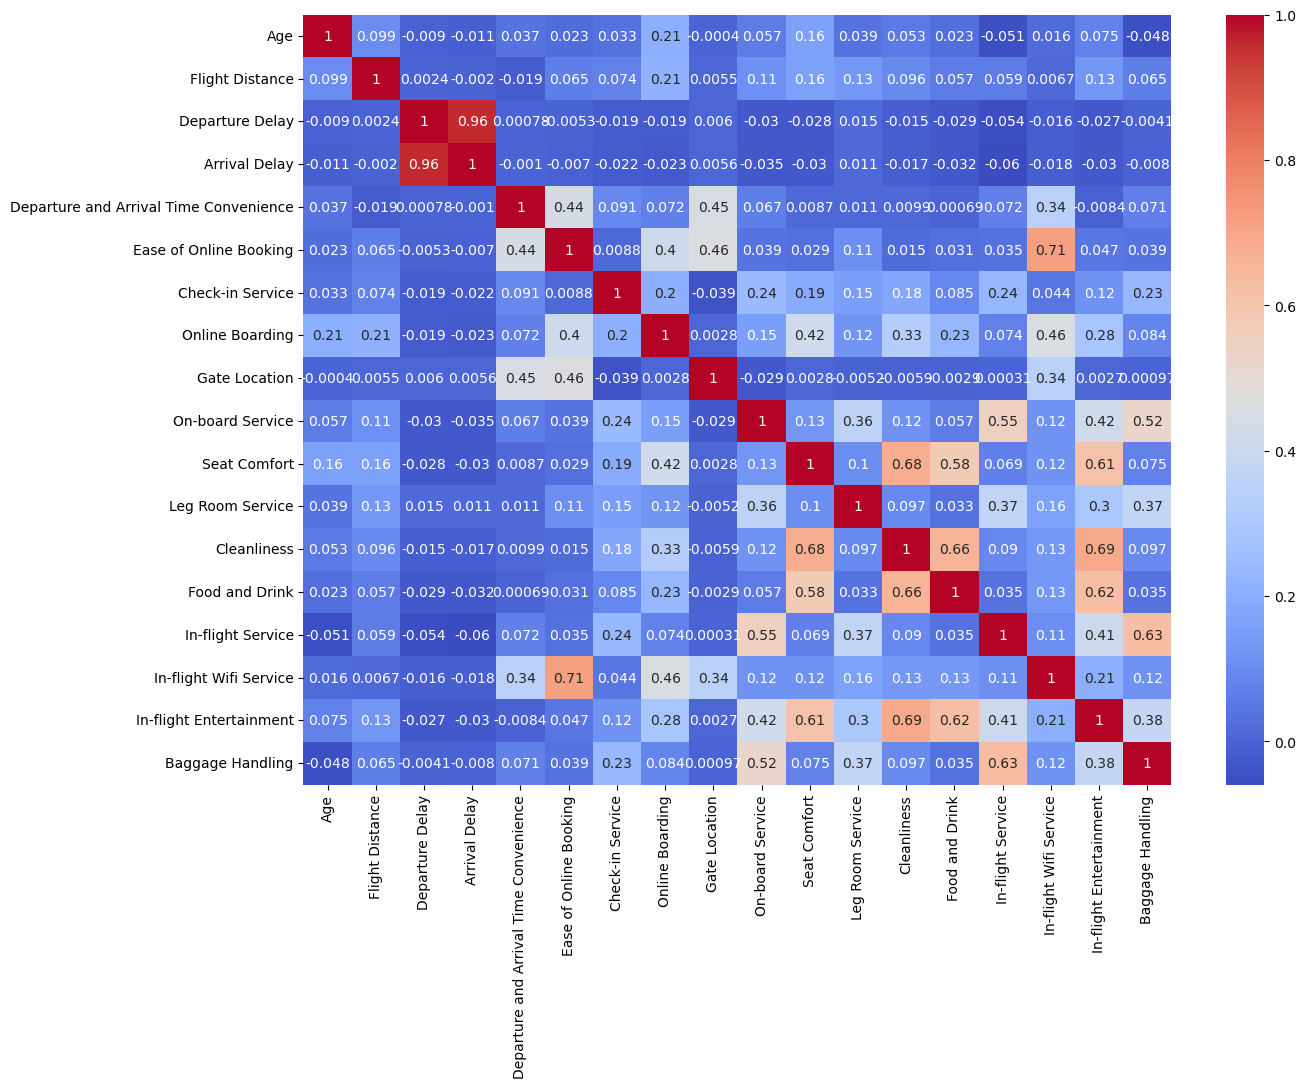

In [23]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.show()

### Outlier Detection

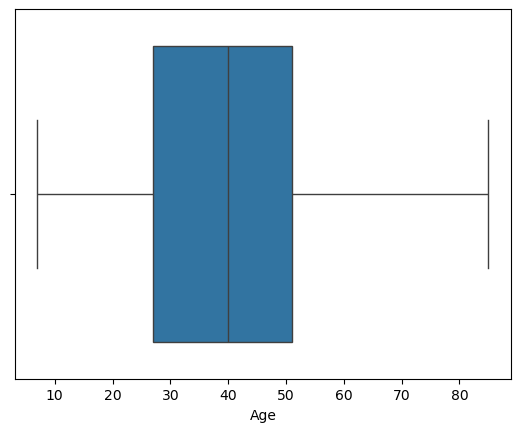

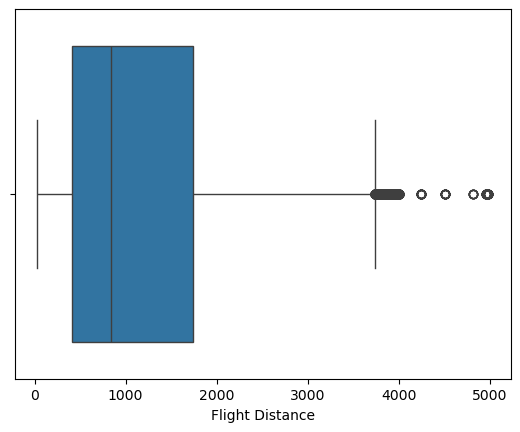

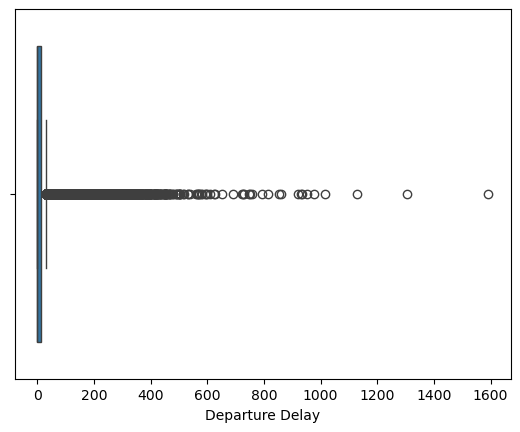

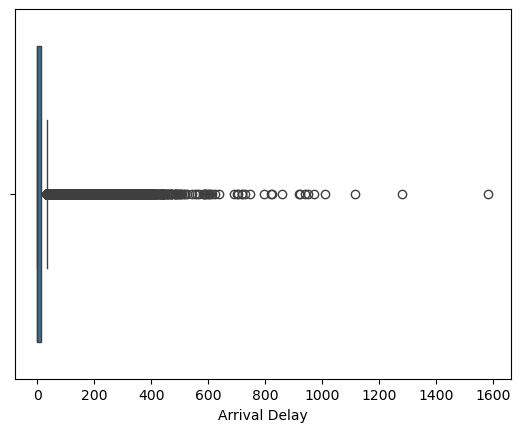

In [24]:
for col in ["Age","Flight Distance","Departure Delay","Arrival Delay"]:
    sns.boxplot(x=df[col])
    plt.show()

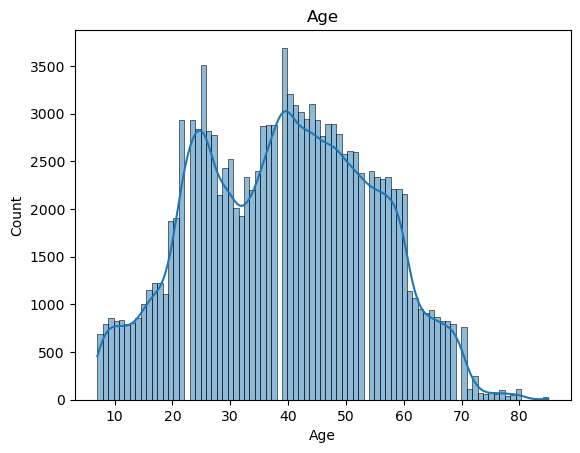

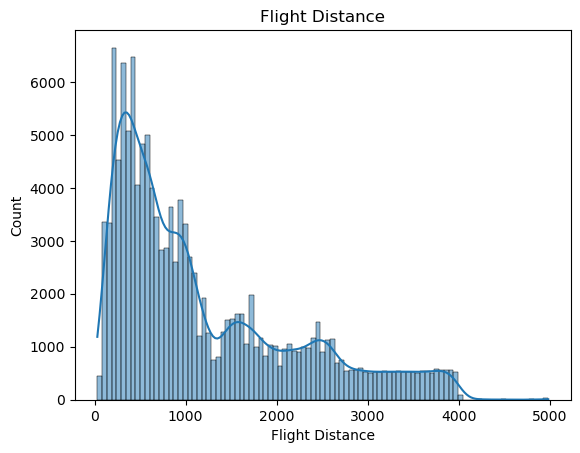

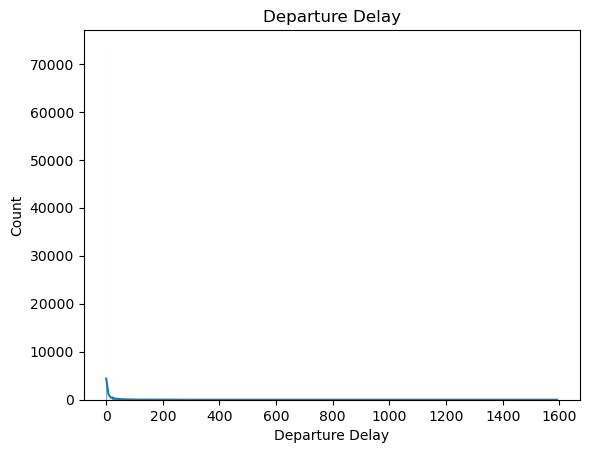

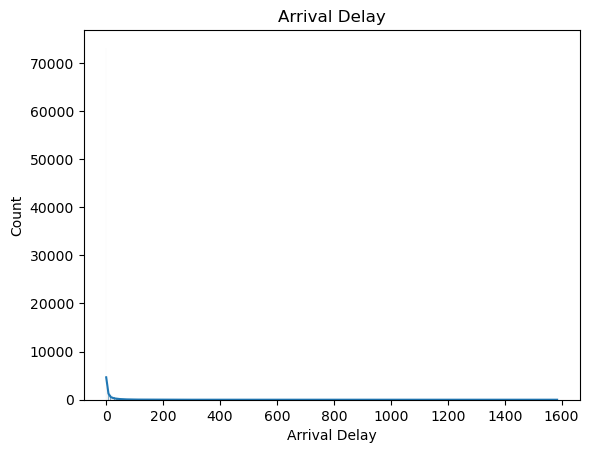

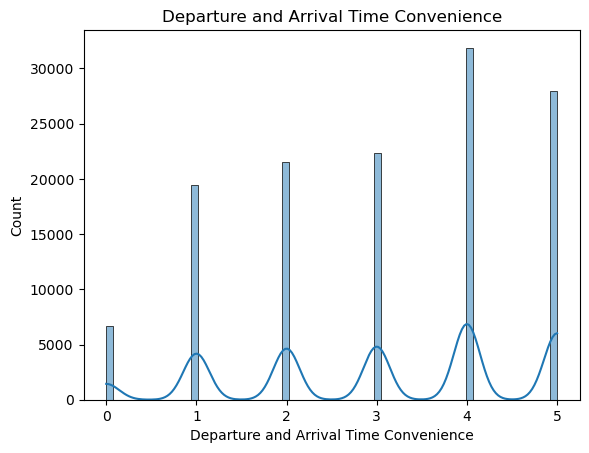

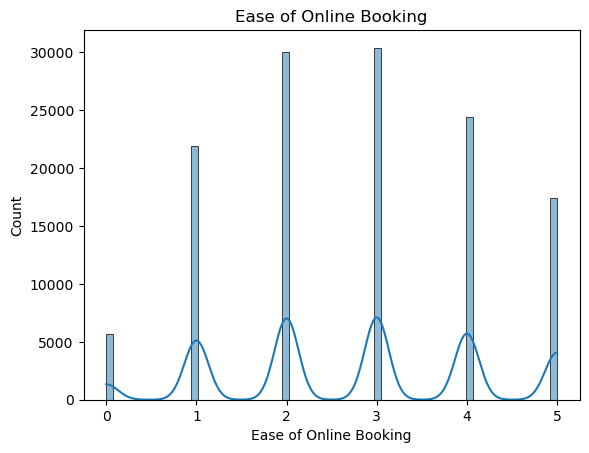

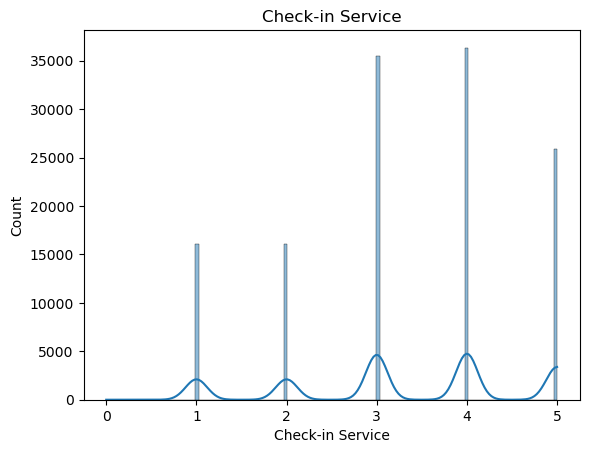

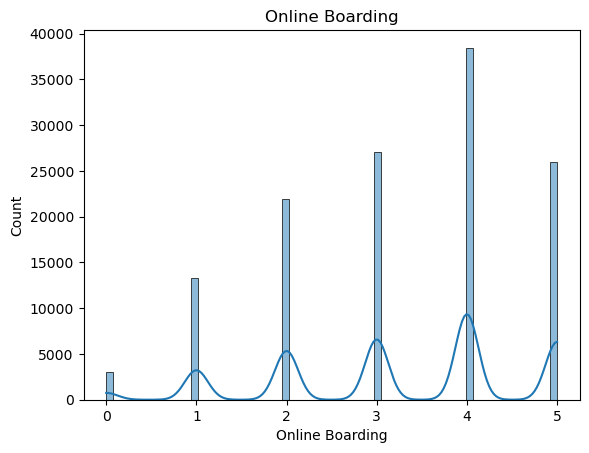

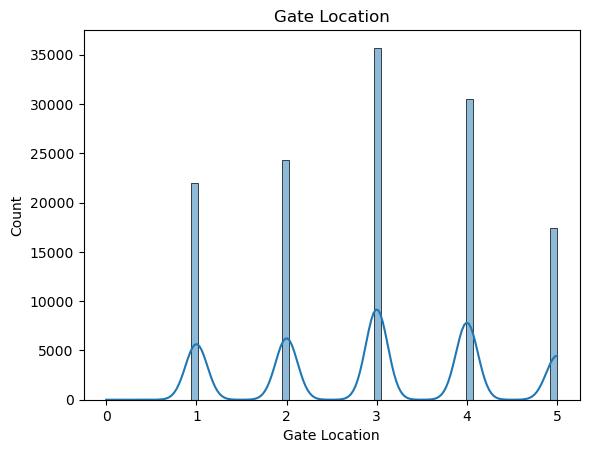

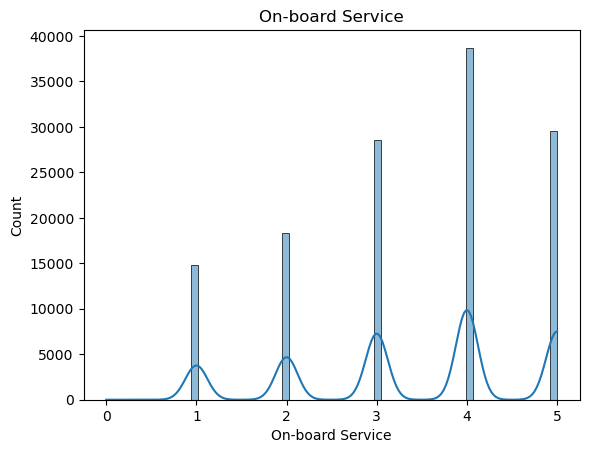

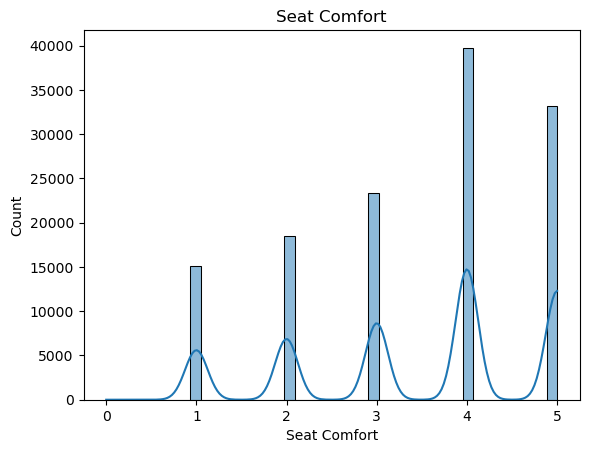

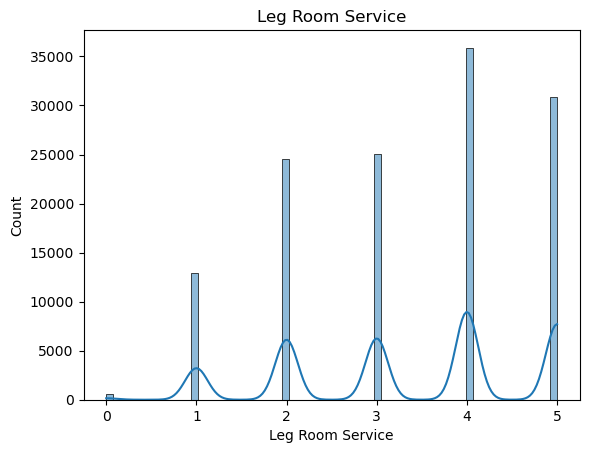

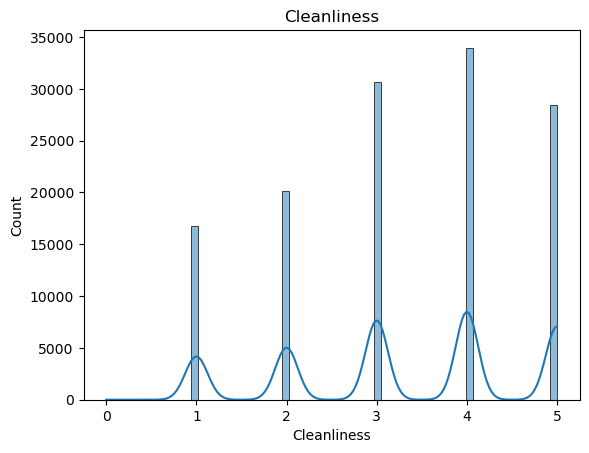

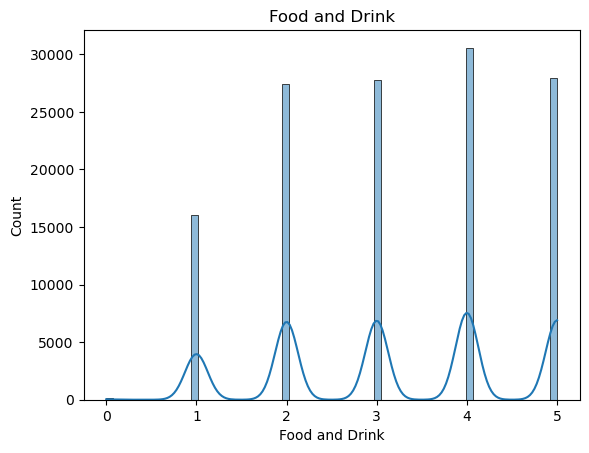

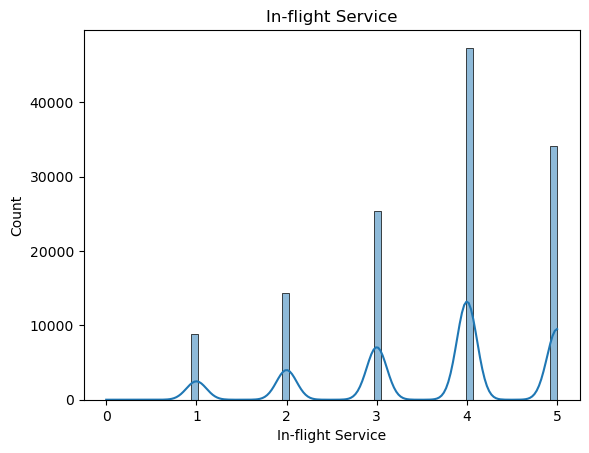

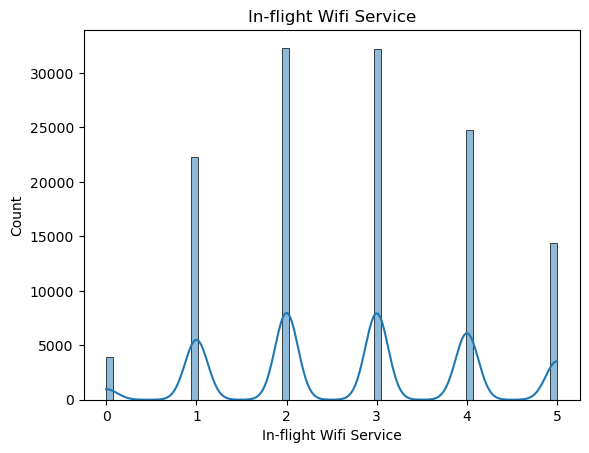

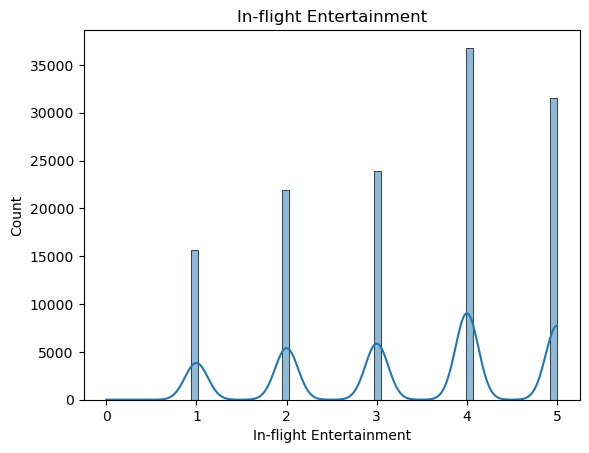

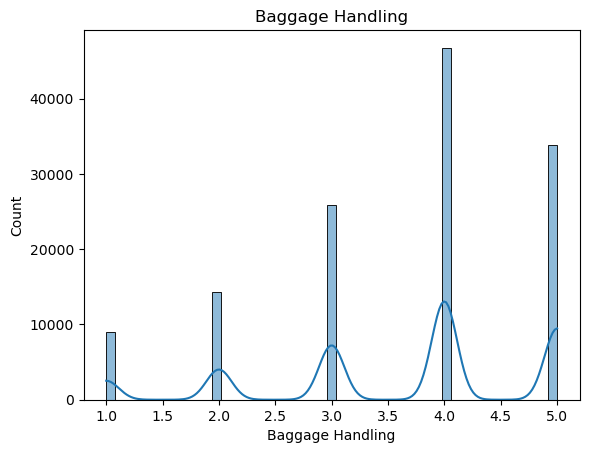

In [25]:
num_cols = df.select_dtypes(include=["int64","float64"])

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()            # Distribution plots for all numerical columns

In [26]:
df.skew(numeric_only = True)    # Identify skewness

Age                                      -0.003606
Flight Distance                           1.108142
Departure Delay                           6.821980
Arrival Delay                             6.678957
Departure and Arrival Time Convenience   -0.332469
Ease of Online Booking                   -0.018779
Check-in Service                         -0.366569
Online Boarding                          -0.456911
Gate Location                            -0.058265
On-board Service                         -0.421320
Seat Comfort                             -0.485818
Leg Room Service                         -0.348414
Cleanliness                              -0.300926
Food and Drink                           -0.155063
In-flight Service                        -0.691580
In-flight Wifi Service                    0.040465
In-flight Entertainment                  -0.366385
Baggage Handling                         -0.677400
dtype: float64

### IQR Detection

In [27]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include="object").columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [28]:
df[col] = df[col].clip(lower, upper)
df[col]

0         5
1         5
2         3
3         5
4         3
         ..
129875    4
129876    5
129877    5
129878    5
129879    1
Name: Baggage Handling, Length: 129880, dtype: int64

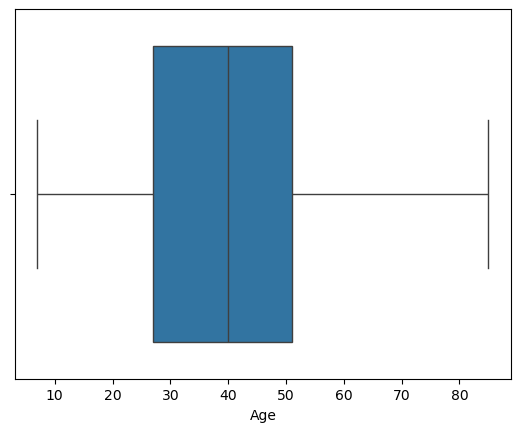

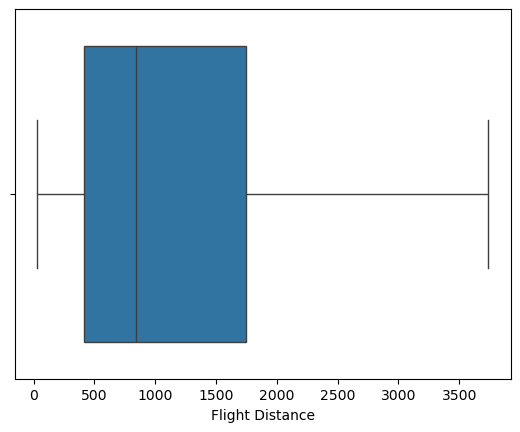

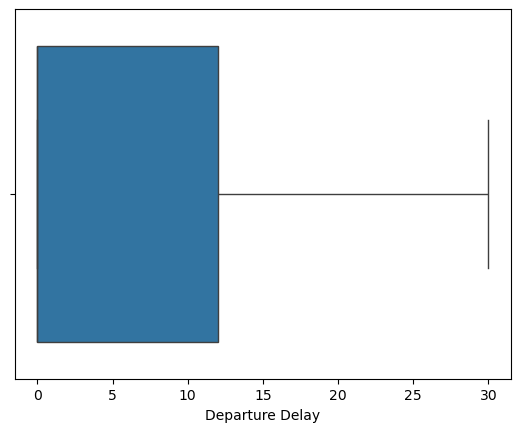

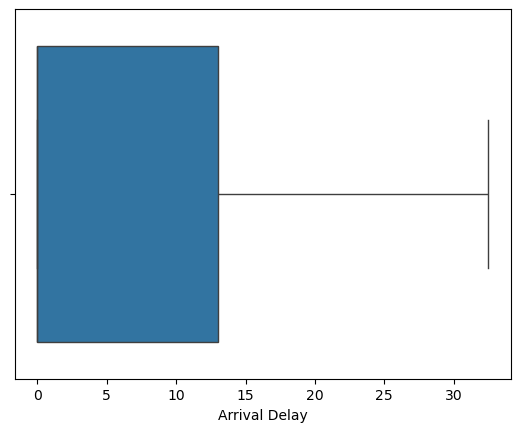

In [29]:
### Check again the BOXPLoT there is not outlier is in the data sset
for col in ["Age","Flight Distance","Departure Delay","Arrival Delay"]:
    sns.boxplot(x=df[col])
    plt.show()

### STEP:4 Feature Engineering

In [30]:
### WE HAVE THE RAW DATA IN THE DATASET SO THE THING IS MLL DOES NOT ALLOW THE MESS DATA FROM EXP: TWO COLUMNS ARE SAME DATA REFE SO WE HAVE TO MERGE THE COLUMNS

In [31]:
df["Total Delay"] = (df["Departure Delay"] +df["Arrival Delay"])
df["Total Delay"]

0          7.0
1         58.5
2          0.0
3          0.0
4          1.0
          ... 
129875     5.0
129876     0.0
129877    20.0
129878    52.0
129879     0.0
Name: Total Delay, Length: 129880, dtype: float64

### here we have add the columns that it prepresent same answer. so we have add the created the Total Delay column

### convert raw numbers into features that better reflect passenger behavior.
### Because exact delay numbers may be less meaningful than the experience category.

In [32]:
def delay_bucket(x):
    if x == 0:
        return "No Delay"
    elif x <= 30:
        return "Minor Delay"
    else:
        return "Major Delay"

df["Delay Category"] = df["Total Delay"].apply(delay_bucket)

### Because exact age may be noisy, while age segments may capture behavior better.

In [33]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0,18,35,50,100],
    labels=["Teen","Young","Adult","Senior"]
)

### STEP:5 Data Preprocessing

In [34]:
### Encode Target

In [35]:
df["Satisfaction"] = df["Satisfaction"].map({"Satisfied": 1,"Neutral or Dissatisfied": 0})
df["Satisfaction"]

0         0
1         1
2         1
3         1
4         1
         ..
129875    0
129876    0
129877    0
129878    1
129879    0
Name: Satisfaction, Length: 129880, dtype: int64

In [36]:
df["Satisfaction"].isna().sum()

np.int64(0)

### Identify categorical columns

In [37]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include="object").columns

### Encode features
- One-hot encoding:

In [38]:
## applying the encoding feature a one-hot encoding
df = pd.get_dummies(df, drop_first=True)

### STEP: 6 Feature / Target Split

In [39]:
x = df.drop('Satisfaction', axis=1)
y = df['Satisfaction']

### STEP:7 Train-Test Split

In [40]:
#### We divide data into two parts:
###- Training set (80%) → model learns patterns
###- Testing set (20%) → model is evaluated on unseen data
 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [41]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_transformed = scaler.fit_transform(x_train)
x_test_transformed = scaler.transform(x_test)

####  SPRINT 2: MODEL BUILDING & EVALUATION

### Step 1: Baseline Model
• Train a simple model:

• Regression → Linear Regression

• Classification → Logistic Regression

• Purpose: Establish performance baseline


In [42]:
### train Logistic regression model
from sklearn.linear_model import LogisticRegression           

model = LogisticRegression(max_iter=1000)

model.fit(x_train_transformed, y_train)

LogisticRegression(max_iter=1000)

####  COMPLETE WORK FLOW OF STEP 2,3,4 

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

# Create Classification Models
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

print("CLASSIFICATION MODEL RESULTS")

# Train and Evaluate Classification Models
for name, model in classification_models.items():

    model.fit(x_train_transformed, y_train)

    y_pred = model.predict(x_test_transformed)

    y_train_pred = model.predict(x_train_transformed)
    y_test_pred = model.predict(x_test_transformed)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"\n{name}")

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("Difference:", abs(train_acc - test_acc))

CLASSIFICATION MODEL RESULTS

Logistic Regression
Accuracy: 0.8762704034493378
Precision: 0.8689307021569528
Recall: 0.841286767972985
F1 Score: 0.8548853169586419
Confusion Matrix:
 [[13295  1428]
 [ 1786  9467]]
Train Accuracy: 0.8749903757314444
Test Accuracy: 0.8762704034493378
Difference: 0.0012800277178933728

Decision Tree
Accuracy: 0.9455651370495842
Precision: 0.933856601111209
Recall: 0.9409935128410202
F1 Score: 0.9374114730878187
Confusion Matrix:
 [[13973   750]
 [  664 10589]]
Train Accuracy: 1.0
Test Accuracy: 0.9455651370495842
Difference: 0.054434862950415774

Random Forest
Accuracy: 0.9619263935940868
Precision: 0.9704803813714705
Recall: 0.9407269172665067
F1 Score: 0.9553720499977438
Confusion Matrix:
 [[14401   322]
 [  667 10586]]
Train Accuracy: 1.0
Test Accuracy: 0.9619263935940868
Difference: 0.038073606405913174

SVM
Accuracy: 0.9521096396673853
Precision: 0.9553270857974706
Recall: 0.9330845107971207
F1 Score: 0.9440748066894443
Confusion Matrix:
 [[14232   4

In [44]:
#### predication the accuracy, predction, f1_score, confusion matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
## predictions 
y_pred = model.predict(x_test_transformed)
y_pred
print("Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression Performance
Accuracy : 0.864490298737296
Precision: 0.8614564831261101
Recall   : 0.8188927397138541
F1 Score : 0.8396355353075171
Confusion Matrix:
 [[13241  1482]
 [ 2038  9215]]


###   Step 2: Train Multiple Models
For Regression:

• Linear Regression

• Decision Tree

• Random Forest

• Gradient Boosting

For Classification:

• Logistic Regression

• Decision Tree

• Random Forest

• SVM

• Naive Bayes



### For Regression:
• Linear Regression
• Decision Tree
• Random Forest
• Gradient Boosting

In [45]:
### here we have imported the regressions algorithms all what are present 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
### HERE WE HAVE IMPORT INTO THE MODEL
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [46]:
#### training the models
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained successfully")

Linear Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully


### For Classification:
• Logistic Regression
• Decision Tree
• Random Forest
• SVM
• Naive Bayes

In [47]:
### IMPORT THE CLASSFICATION ALL THE ALGORITHMS
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
### Create Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Navie Bayes": GaussianNB()
}
### training the models
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained successfully")

C:\Users\shash\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
SVM trained successfully
Navie Bayes trained successfully


###  Step 3: Model Evaluation
Regression Metrics:

• MAE

• RMSE

• R²

Classification Metrics:

• Accuracy

• Precision

• Recall

• F1 Score

• Confusion Matrix


In [48]:
### importing the Regression metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

### Evaluate All Regression Models

In [49]:
for name, model in models.items():

    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)


Logistic Regression
MAE : 0.12353711117955035
RMSE: 0.3514784647450685
R²  : 0.496873303919275

Decision Tree
MAE : 0.054242377579303974
RMSE: 0.23289993039780835
R²  : 0.7790883406738106

Random Forest
MAE : 0.038343085925469665
RMSE: 0.19581390636384757
R²  : 0.8438410129958236

SVM
MAE : 0.3291499846011703
RMSE: 0.5737159441754868
R²  : -0.34052142458404466

Navie Bayes
MAE : 0.13550970126270404
RMSE: 0.36811642351666957
R²  : 0.44811281701335237


In [50]:
### importing the classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### Evaluate All Classification Models

In [51]:
for name, model in models.items():

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Confusion Matrix:\n", cm)


Logistic Regression
Accuracy : 0.8764628888204496
Precision: 0.8691262848751835
Recall   : 0.8415533635474984
F1 Score : 0.8551176125332972
Confusion Matrix:
 [[13297  1426]
 [ 1783  9470]]

Decision Tree
Accuracy : 0.945757622420696
Precision: 0.9347288464935524
Recall   : 0.9404603216919932
F1 Score : 0.9375858250276855
Confusion Matrix:
 [[13984   739]
 [  670 10583]]

Random Forest
Accuracy : 0.9616569140745304
Precision: 0.9698579935868071
Recall   : 0.9407269172665067
F1 Score : 0.955070371706965
Confusion Matrix:
 [[14394   329]
 [  667 10586]]

SVM
Accuracy : 0.6708500153988297
Precision: 0.6830556684274685
Recall   : 0.44814716075713146
F1 Score : 0.5412105602060528
Confusion Matrix:
 [[12383  2340]
 [ 6210  5043]]

Navie Bayes
Accuracy : 0.864490298737296
Precision: 0.8609840351040986
Recall   : 0.8195147960543855
F1 Score : 0.8397377526862138
Confusion Matrix:
 [[13234  1489]
 [ 2031  9222]]


###  Step 4: Overfitting & Underfitting Check

• Compare: Training vs Testing performance


In [52]:
from sklearn.metrics import accuracy_score

for name, model in models.items():

    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"\n{name}")
    print("Training Accuracy:", train_acc)
    print("Testing Accuracy :", test_acc)

    # Check
    if train_acc > test_acc + 0.10:
        print("Status: Overfitting")
    elif train_acc < 0.70 and test_acc < 0.70:
        print("Status: Underfitting")
    else:
        print("Status: Good Fit")


Logistic Regression
Training Accuracy: 0.8749326301201109
Testing Accuracy : 0.8764628888204496
Status: Good Fit

Decision Tree
Training Accuracy: 1.0
Testing Accuracy : 0.945757622420696
Status: Good Fit

Random Forest
Training Accuracy: 1.0
Testing Accuracy : 0.9616569140745304
Status: Good Fit

SVM
Training Accuracy: 0.6701763165999384
Testing Accuracy : 0.6708500153988297
Status: Underfitting

Navie Bayes
Training Accuracy: 0.8615356482907299
Testing Accuracy : 0.864490298737296
Status: Good Fit


### Step 5: Model Comparison Table


In [53]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

comparison = []

for name, model in models.items():

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)

    if train_r2 > r2 + 0.10:
        status = "Yes"
        remark = "Overfitting"
    elif train_r2 < 0.70 and r2 < 0.70:
        status = "No"
        remark = "Underfitting"
    else:
        status = "No"
        remark = "Good Fit"

    comparison.append([name, round(r2, 4), status, remark])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Model", "Metric Score (R²)", "Overfitting?", "Remarks"]
)

comparison_df

,Model,Metric Score (R²),Overfitting?,Remarks
0,Logistic Regression,0.4969,No,Underfitting
1,Decision Tree,0.7791,Yes,Overfitting
2,Random Forest,0.8438,Yes,Overfitting
3,SVM,-0.3405,No,Underfitting
4,Navie Bayes,0.4481,No,Underfitting


##### Step 5: Model Comparison Table

We compare all models in one table.

Example:

Model	Accuracy	Overfitting	Remarks

Logistic Regression	88%	No	Good baseline

Decision Tree	84%	Yes	Overfitting

Random Forest	93%	No	Best performer

SVM	91%	No	Strong model

Naive Bayes	85%	No	Fast but lower accuracy

### SPRINT 3: OPTIMIZATION & FINAL MODEL


### Step 1: Feature Engineering
• Create new features:

• Ratios

• Aggregations

• Domain-specific transformations


# 1. Ratio Features

In [56]:
df["Distance_per_Age"] = df["Flight Distance"] / (df["Age"] + 1)

df["Delay_Ratio"] = (
    df["Departure Delay"] /
    (df["Arrival Delay"] + 1)
)

## 2. Aggregation Features

Combine multiple service-related features into a single score.

In [58]:
service_cols = [
    "In-flight Wifi Service",
    "Food and Drink",
    "Seat Comfort",
    "In-flight Entertainment",
    "On-board Service",
    "Cleanliness"
]

df["Total_Service_Score"] = df[service_cols].sum(axis=1)

df["Average_Service_Score"] = df[service_cols].mean(axis=1)

## 3. Domain-Specific Transformations

Use airline business knowledge.

Total Delay

In [63]:
df["Total_Delay"] = (
    df["Departure Delay"] +
    df["Arrival Delay"]
)

- Travel Experience Score

In [65]:
df["Travel_Experience"] = (
    df["Seat Comfort"] +
    df["Food and Drink"] +
    df["In-flight Entertainment"]
)

##  Step 2: Feature Selection
• Remove: Irrelevant features, Highly correlated features

• Methods:

• Correlation matrix

• Feature importance

• Recursive Feature Elimination (RFE)


# Method 1: Correlation Matrix

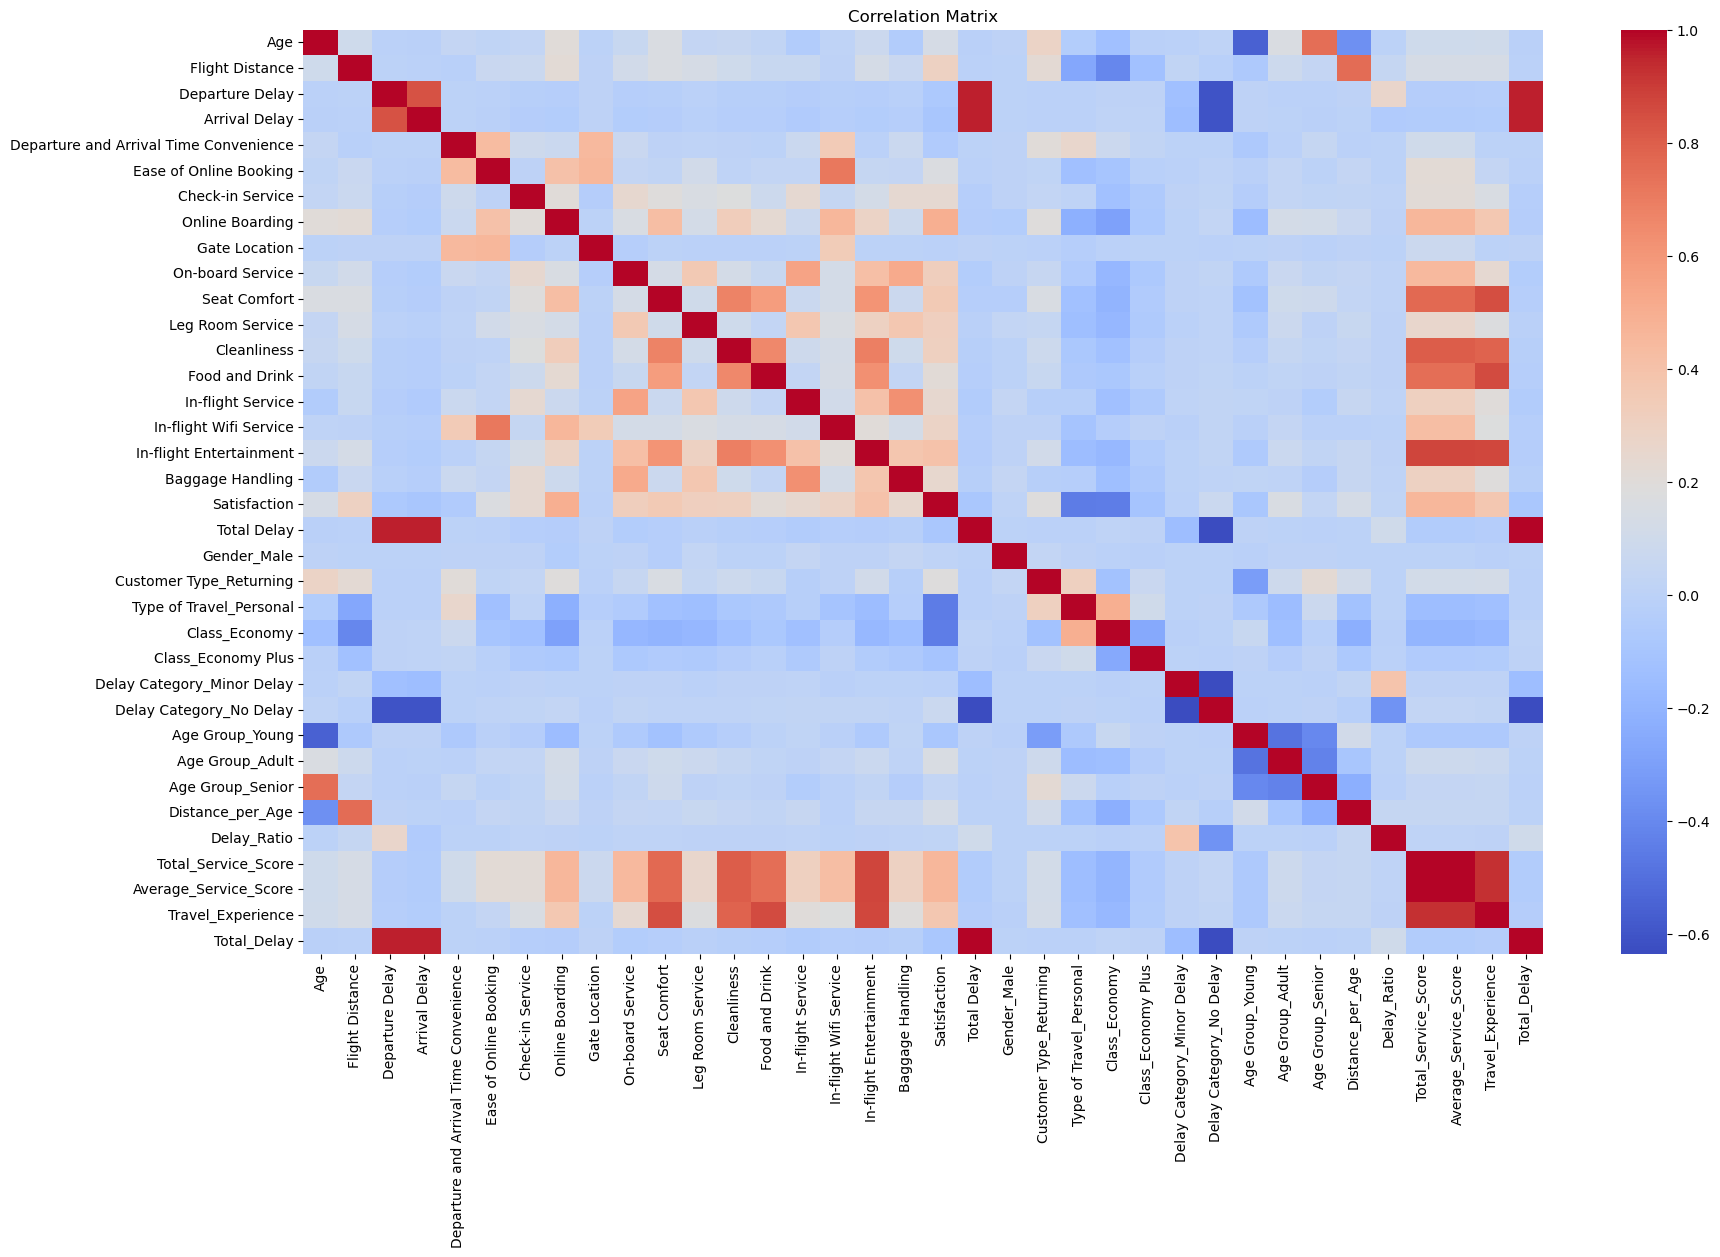

In [67]:
# Feature Selection using Correlation Matrix

# Purpose:
# 1. Identify relationships between features.
# 2. Detect highly correlated (redundant) features.
# 3. Reduce multicollinearity.
# 4. Improve model efficiency and generalization.
# 5. Keep only the most useful features for training.

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Feature Importance:

In [70]:
# Feature Importance Analysis

# Purpose:
# 1. Determine which features contribute most to predictions.
# 2. Identify low-impact features.
# 3. Improve model interpretability.
# 4. Help select the most relevant features.

from sklearn.ensemble import RandomForestClassifier

# Recursive Feature Elimination (RFE)

In [71]:
# Recursive Feature Elimination (RFE)

# Purpose:
# 1. Automatically select the best features.
# 2. Remove less important features.
# 3. Reduce overfitting.
# 4. Improve model performance.
# 5. Build a simpler and more efficient model.

## Step 3: Hyperparameter Tuning

• Use: GridSearchCV, RandomizedSearchCV

• Tune: Model-specific parameters

In [72]:
# Hyperparameter Tuning

# Purpose:
# 1. Find the best parameter combination for the model.
# 2. Improve prediction accuracy.
# 3. Reduce overfitting and underfitting.
# 4. Improve model generalization on unseen data.
# 5. Optimize model performance automatically.

# A hyperparameter is a setting that we choose before training the model.

# Method 1: GridSearchCV

- It tries every possible combination of parameters.

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# GridSearchCV:
# Tests all possible parameter combinations.
# Finds the optimal settings for maximum performance.

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best Score: 0.9610794509069536


# Method 2: RandomizedSearchCV

Instead of checking all combinations, it randomly tests a subset.

In [74]:
# RandomizedSearchCV:
# Randomly samples parameter combinations.
# Faster than GridSearchCV for large search spaces.

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 400, 'min_samples_split': 2, 'max_depth': 30}
Best Score: 0.9611564424618086


# Step 4: Build Final Model

# Purpose:
 1. Train the model using the selected features.
 2. Use the best hyperparameters found during tuning.
 3. Build the most accurate version of the model.
 4. Prepare the model for final evaluation.
 5. Create a production-ready model for deployment.

# Final Model Training

In [75]:
# Train the final optimized model using:
# • Selected Features
# • Best Hyperparameters

final_model = grid_search.best_estimator_

final_model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

# Step 5: Final Evaluation
• Evaluate on unseen test data


In [77]:
# Step 5: Final Evaluation

# Why are we doing this?
# • Evaluate the final optimized model on unseen test data.
# • Measure how well the model generalizes to new data.
# • Verify improvements from feature selection and hyperparameter tuning.
# • Check the model's real-world prediction performance.
# • Confirm the model is ready for deployment.

# Step 5: Final Evaluation
• Evaluate on unseen test data


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Predictions on unseen test data
y_pred = final_model.predict(x_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.962580843855867
Precision: 0.9710437093374874
Recall   : 0.9417044343730561
F1 Score : 0.9561490571144997

Confusion Matrix:
[[14407   316]
 [  656 10597]]


# Step 6: Model Serialization

In [ ]:
# Step 6: Model Serialization

# Purpose:
# • Save the trained model to a file.
# • Avoid retraining the model every time.
# • Reuse the model for future predictions.
# • Deploy the model in Streamlit, Flask, or Web Applications.
# • Make the project production-ready.


In [78]:
import joblib

# Save model
joblib.dump(final_model, "airline_satisfaction_model.joblib")

print("Model Saved Successfully")

Model Saved Successfully


In [79]:
import joblib

loaded_model = joblib.load("airline_satisfaction_model.joblib")
loaded_model

RandomForestClassifier(n_estimators=300, random_state=42)

### SPRINT 4: DEPLOYMENT & MLOPS
Goal: Make model usable in real-world applications

  Step 1: Build ML Pipeline
  
• Combine: Preprocessing + Model

• Use pipeline structure

  Step 2: Frontend
  
• Build UI using Streamlit

• Features:

• User inputs

• Prediction display

  Step 3: Deployment
  
• Deploy model: Local / Cloud platforms

  Step 4: MLOps Practices
  
Version Control

• Use GitHub

Experiment Tracking

• Track: Models, Metrics, Parameters

Logging & Monitoring

• Log predictions

• Monitor model performance


# Step 1: Build ML Pipeline

In [80]:
# Step 1: Build ML Pipeline

# Purpose:
# • Combine preprocessing and model into one workflow.
# • Ensure the same preprocessing is applied during training and prediction.
# • Reduce manual errors.
# • Simplify deployment.
# • Create a reusable prediction pipeline.

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42
    ))
])

pipeline.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=20, n_estimators=300,
                                        random_state=42))])

In [87]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=300, random_state=42)

In [89]:
import joblib

joblib.dump(model, "airline_model.joblib")

['airline_model.joblib']

In [90]:
print(model.feature_names_in_)

['Age' 'Flight Distance' 'Online Boarding' 'Seat Comfort'
 'In-flight Wifi Service' 'Food and Drink']


In [83]:
print(x_train.columns.tolist())

['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Total Delay', 'Gender_Male', 'Customer Type_Returning', 'Type of Travel_Personal', 'Class_Economy', 'Class_Economy Plus', 'Delay Category_Minor Delay', 'Delay Category_No Delay', 'Age Group_Young', 'Age Group_Adult', 'Age Group_Senior']


In [91]:
X = df[
    [
        "Age",
        "Flight Distance",
        "Online Boarding",
        "Seat Comfort",
        "In-flight Wifi Service",
        "Food and Drink"
    ]
]

In [93]:
import joblib

joblib.dump(
    model,
    "airline_model_compressed.joblib",
    compress=3
)

['airline_model_compressed.joblib']

In [94]:
import os

size_mb = os.path.getsize(
    "airline_model_compressed.joblib"
) / (1024 * 1024)

print(f"Size: {size_mb:.2f} MB")

Size: 64.22 MB
